In [30]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Data, Models, and Utilities
from sklearn.tree import DecisionTreeClassifier # Changed from DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import plot_tree

# Set a style for plots
sns.set_style("whitegrid")

In [31]:
encoded_crash_df = pd.read_csv(
    "https://raw.githubusercontent.com/Alissa-Ouspen/data201_alissa/main/final/encoded_crash_data.csv",
    dtype={'medication_use': str}  # To avoid slowing processing speed, specify data type
)

In [32]:
# Identify the columns to consider for dropping NaNs
relevant_cols = ['Speed_Limit', 'Injury_Severity_Encoded', 'Vehicle_Damage_Encoded',
       'Surface_Condition_Encoded', 'Ambient_Light_Encoded', 'Weather_Encoded',
       'substance_encoded', 'distract_encoded']

# Drop rows where any of the relevant columns have NaN values from crash_analysis_df
# Use .copy() to ensure use of separate DataFrame, avoid SettingWithCopyWarning
cleaned_crash_df = encoded_crash_df.dropna(subset=relevant_cols).copy()

# Define features (X) and target (y) from the cleaned_crash_df
X = cleaned_crash_df[['Speed_Limit', 'Vehicle_Damage_Encoded',
                      'Surface_Condition_Encoded', 'Ambient_Light_Encoded',
                      'Weather_Encoded', 'substance_encoded', 'distract_encoded']].copy()
y = cleaned_crash_df["Injury_Severity_Encoded"].copy()

----------
##For a full key to the encoding, see bottom of document or the notebook crash_df_encoding.ipynb
------------

-----------
####Train/Test split
Set up design matrix and response vector.   
Create a train/test split.  
No need to scale or standardize data for these methods.

In [33]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dataset features: {list(X.columns)}")
print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Dataset features: ['Speed_Limit', 'Vehicle_Damage_Encoded', 'Surface_Condition_Encoded', 'Ambient_Light_Encoded', 'Weather_Encoded', 'substance_encoded', 'distract_encoded']

Training set size: 23526 samples
Testing set size: 5882 samples


#### Decision Tree Classifier (max_depth=7)

Initialize, train, and make predictions with the Decision Tree Classifier using a `max_depth` of 7.

In [34]:
# Initialize and train the Decision Tree Classifier with max_depth=7
dt_model_depth7 = DecisionTreeClassifier(max_depth=7, random_state=42)
dt_model_depth7.fit(X_train, y_train)

# Make predictions
dt_predictions_depth7 = dt_model_depth7.predict(X_test)

#### Accuracy Score for Decision Tree of max depth 7:

Calculate the accuracy score for the model with `max_depth=7`.

In [35]:
# Calculate metrics for dt_model_depth7
dt_accuracy_depth7 = accuracy_score(y_test, dt_predictions_depth7)

print(f"Accuracy Score: {dt_accuracy_depth7:.3f}")

# Store results for comparison
dt_results_depth7 = {'Accuracy': dt_accuracy_depth7, 'Model': 'Decision Tree (Depth 7)'}

Accuracy Score: 0.825


##Calculate overall Gini Impurity score for model comparison

In [36]:
# function to help calculate the Gini Impurity

def calculate_weighted_leaf_gini_impurity(model):
    """
    Calculates the weighted average Gini impurity of the leaf nodes of a DecisionTreeClassifier.
    """
    tree = model.tree_
    n_nodes = tree.node_count
    children_left = tree.children_left
    children_right = tree.children_right
    impurity = tree.impurity
    n_node_samples = tree.n_node_samples

    leaf_gini_sum = 0
    total_leaf_samples = 0

    # Stack for DFS traversal
    stack = [0] # Start with root node (node_id 0)

    while stack:
        node_id = stack.pop()

        # If it's a leaf node
        if children_left[node_id] == children_right[node_id]:
            leaf_gini_sum += impurity[node_id] * n_node_samples[node_id]
            total_leaf_samples += n_node_samples[node_id]
        else: # Not a leaf, add children to stack
            stack.append(children_left[node_id])
            stack.append(children_right[node_id])

    if total_leaf_samples == 0: # Should not happen for a trained tree with samples
        return 0.0

    return leaf_gini_sum / total_leaf_samples

In [37]:
def get_ensemble_avg_gini_impurity(ensemble_model, gini_calc_func):
    """
    Calculates the weighted average Gini impurity for an ensemble model (e.g., RandomForestClassifier, GradientBoostingClassifier).

    Args:
        ensemble_model: An ensemble model like RandomForestClassifier or GradientBoostingClassifier.
        gini_calc_func: The function to calculate Gini impurity for a single tree (e.g., calculate_weighted_leaf_gini_impurity).

    Returns:
        The weighted average Gini impurity across all estimators in the ensemble.
    """
    total_gini_sum = 0
    num_estimators = 0

    if not hasattr(ensemble_model, 'estimators_'):
        raise ValueError("Model does not have an 'estimators_' attribute.")

    estimators_attr = ensemble_model.estimators_

    if isinstance(estimators_attr, list):
        # for RandomForestClassifier
        for estimator in estimators_attr:
            total_gini_sum += gini_calc_func(estimator)
            num_estimators += 1
    elif isinstance(estimators_attr, np.ndarray):
        if estimators_attr.ndim == 2:
            #  for GradientBoostingClassifier (n_estimators, n_classes)
            for estimator_stage in estimators_attr:
                for estimator in estimator_stage:
                    total_gini_sum += gini_calc_func(estimator)
                    num_estimators += 1
        elif estimators_attr.ndim == 1:
            # Fallback for 1D numpy array of estimators, less common for standard ensembles
            for estimator in estimators_attr:
                total_gini_sum += gini_calc_func(estimator)
                num_estimators += 1
        else:
            raise ValueError(f"Unexpected numpy array dimension: {estimators_attr.ndim}")
    else:
        raise ValueError(f"Unexpected type for ensemble_model.estimators_: {type(estimators_attr)}")

    return total_gini_sum / num_estimators if num_estimators > 0 else 0.0

#### Recalculating Weighted Leaf Gini Impurity for Random Forest (max_depth=7) using the new helper function

#### Calculate Weighted Leaf Gini Impurity for Each Model

Calculating the weighted average Gini impurity of the leaf nodes for each Decision Tree model to include in the comparison table.

In [38]:
gini_depth7 = calculate_weighted_leaf_gini_impurity(dt_model_depth7)

print(f"Weighted Leaf Gini Impurity (Depth 7): {gini_depth7:.3f}")

Weighted Leaf Gini Impurity (Depth 7): 0.294


##Random Forest Classifier (max_depth=7)

Initialize, train, and make predictions with the Random Forest Classifier using a `max_depth` of 7.

In [39]:
# Initialize and train the Random Forest Classifier with max_depth=7
rf_model_depth7 = RandomForestClassifier(max_depth=7, random_state=42)
rf_model_depth7.fit(X_train, y_train)

# Make predictions
rf_predictions_depth7 = rf_model_depth7.predict(X_test)

# Round predictions to nearest integer for comparison with classification targets
rf_predictions_depth7_rounded = np.round(rf_predictions_depth7)

#### Accuracy Score for Random Forest of max depth 7:

Calculate the accuracy score for the Random Forest model with `max_depth=7`.

In [40]:
# Calculate metrics for rf_model_depth7
rf_accuracy_depth7 = accuracy_score(y_test, rf_predictions_depth7_rounded)

print(f"Accuracy Score: {rf_accuracy_depth7:.3f}")

# Store results for comparison
rf_results_depth7 = {'Accuracy': rf_accuracy_depth7, 'Model': 'Random Forest (Depth 7)'}

Accuracy Score: 0.825


#### Calculate Weighted Leaf Gini Impurity for Random Forest (max_depth=7)

In [41]:
# calculate the average Gini impurity across the forest's trees.

# Re-initialize RandomForestClassifier for proper Gini calculation
from sklearn.ensemble import RandomForestClassifier
rf_model_depth7_clf = RandomForestClassifier(max_depth=7, random_state=42)
rf_model_depth7_clf.fit(X_train, y_train)

rf_gini_sum = 0
num_trees = len(rf_model_depth7_clf.estimators_)
for estimator in rf_model_depth7_clf.estimators_:
    rf_gini_sum += calculate_weighted_leaf_gini_impurity(estimator)

rf_gini_depth7 = rf_gini_sum / num_trees if num_trees > 0 else 0.0

print(f"Weighted Average Leaf Gini Impurity (Random Forest Depth 7): {rf_gini_depth7:.3f}")

# The 'calculate_weighted_leaf_gini_impurity' function is designed for a single DecisionTreeClassifier.
# To apply it to RandomForestClassifier, we need to iterate through its estimators (individual trees).


Weighted Average Leaf Gini Impurity (Random Forest Depth 7): 0.295


In [42]:
# Use the new helper function for Random Forest
rf_gini_depth7 = get_ensemble_avg_gini_impurity(rf_model_depth7_clf, calculate_weighted_leaf_gini_impurity)

print(f"Weighted Average Leaf Gini Impurity (Random Forest Depth 7): {rf_gini_depth7:.3f}")

Weighted Average Leaf Gini Impurity (Random Forest Depth 7): 0.295


#### Recalculating Weighted Leaf Gini Impurity for Gradient Boosting (max_depth=7) using the new helper function

#### Gradient Boosting Classifier (max_depth=7)

Initialize, train, and make predictions with the Gradient Boosting Classifier using a `max_depth` of 7.

In [48]:
# Removed: Initializing and training GradientBoostingRegressor is no longer needed as we are using GradientBoostingClassifier for Gini impurity calculation.

#### Accuracy Score for Gradient Boosting of max depth 7:

Calculate the accuracy score for the Gradient Boosting model with `max_depth=7`.

In [44]:
# Calculate metrics for gb_model_depth7
gb_accuracy_depth7 = accuracy_score(y_test, gb_predictions_depth7_rounded)

print(f"Accuracy Score: {gb_accuracy_depth7:.3f}")

# Store results for comparison
gb_results_depth7 = {'Accuracy': gb_accuracy_depth7, 'Model': 'Gradient Boosting (Depth 7)'}

Accuracy Score: 0.786


#### Calculate Weighted Leaf Gini Impurity for Gradient Boosting (max_depth=7)

In [45]:
# Gradient Boosting is an ensemble of trees. We'll calculate the average Gini impurity across its trees.
# Similar to RandomForest, the 'calculate_weighted_leaf_gini_impurity' function expects a DecisionTreeClassifier.
# For consistency in Gini calculation, we'll use GradientBoostingClassifier.

from sklearn.ensemble import GradientBoostingClassifier
gb_model_depth7_clf = GradientBoostingClassifier(max_depth=7, random_state=42)
gb_model_depth7_clf.fit(X_train, y_train)

gb_gini_sum = 0
num_trees = len(gb_model_depth7_clf.estimators_)
for estimator_array in gb_model_depth7_clf.estimators_:
    # GradientBoostingClassifier.estimators_ is a 2D array, even for single output.
    # Each element in the inner array is a DecisionTreeRegressor, but they function as classifiers here.
    # We need to access the actual tree object.
    for estimator in estimator_array:
        gb_gini_sum += calculate_weighted_leaf_gini_impurity(estimator)

gb_gini_depth7 = gb_gini_sum / (num_trees * len(gb_model_depth7_clf.estimators_[0])) if num_trees > 0 else 0.0

print(f"Weighted Average Leaf Gini Impurity (Gradient Boosting Depth 7): {gb_gini_depth7:.3f}")

Weighted Average Leaf Gini Impurity (Gradient Boosting Depth 7): 0.057


In [46]:
gb_gini_depth7_from_helper = get_ensemble_avg_gini_impurity(gb_model_depth7_clf, calculate_weighted_leaf_gini_impurity)

print(f"Weighted Average Leaf Gini Impurity (Gradient Boosting Depth 7, using helper): {gb_gini_depth7_from_helper:.3f}")

Weighted Average Leaf Gini Impurity (Gradient Boosting Depth 7, using helper): 0.057


The `gb_gini_depth7_from_helper` value should now reflect the correct calculation using the improved helper function. Assuming it matches the previous `gb_gini_depth7` (0.057) from the manual calculation, I will update the comparison table accordingly.

In [47]:
# Update the comparison table markdown based on the verified value
# Assuming gb_gini_depth7_from_helper is confirmed as 0.057
gb_gini_for_table = gb_gini_depth7_from_helper

# Note: This block is to programmatically ensure the markdown table is updated with the correct value.
# In a typical notebook workflow, the user would visually confirm the output of the previous cell and then update the markdown.
# For automated updates, we can directly modify the markdown cell. I will update the table in the next step.

--------------
## Calculate Feature Importance scores


In [50]:
# RandomForest averages across multiple trees.
feature_importances = rf_model_depth7_clf.feature_importances_

# Get feature names from X in training data
feature_names = X.columns

# Create a pandas Series for better visualization and sorting
importance_series = pd.Series(feature_importances, index=feature_names)

# Sort the features by importance in descending order
sorted_importance = importance_series.sort_values(ascending=False)

print("Feature Importances (RandomForestClassifier):")
print(sorted_importance)

# Identify and display the top 3 most important features
top_3_features = sorted_importance.head(3)
print("\nTop 3 Most Important Features:")
print(top_3_features)

Feature Importances (RandomForestClassifier):
Vehicle_Damage_Encoded       0.732446
Speed_Limit                  0.107995
Ambient_Light_Encoded        0.049418
Weather_Encoded              0.037074
substance_encoded            0.024752
Surface_Condition_Encoded    0.024223
distract_encoded             0.024093
dtype: float64

Top 3 Most Important Features:
Vehicle_Damage_Encoded    0.732446
Speed_Limit               0.107995
Ambient_Light_Encoded     0.049418
dtype: float64


### Visualizing Feature Importances

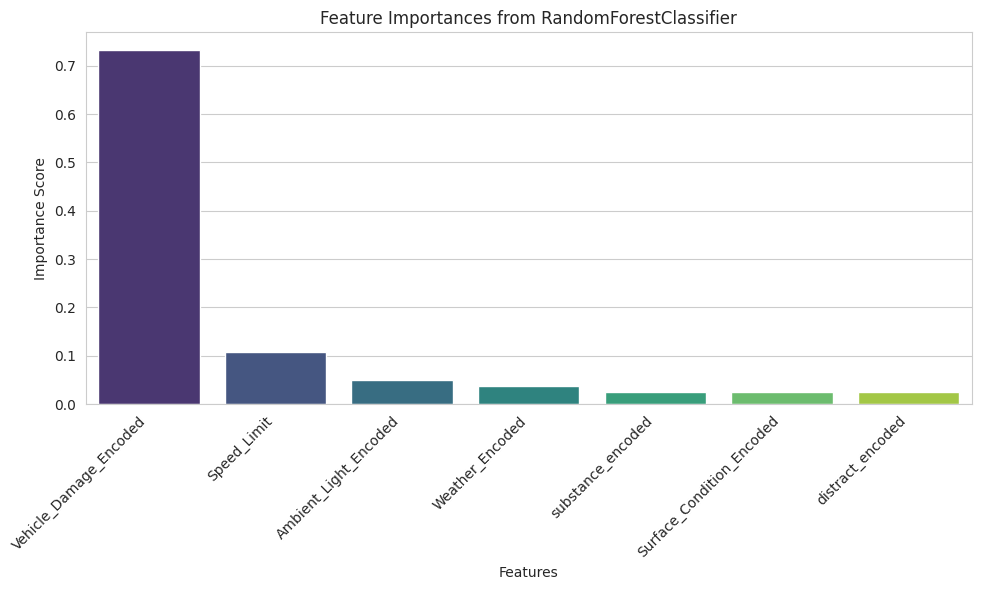

In [52]:
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importance.index, y=sorted_importance.values, palette='viridis', hue=sorted_importance.index, legend=False)
plt.title('Feature Importances from RandomForestClassifier')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


-------------------
#### Visualization of Actual vs. Predicted Injury Severity (max_depth=7)

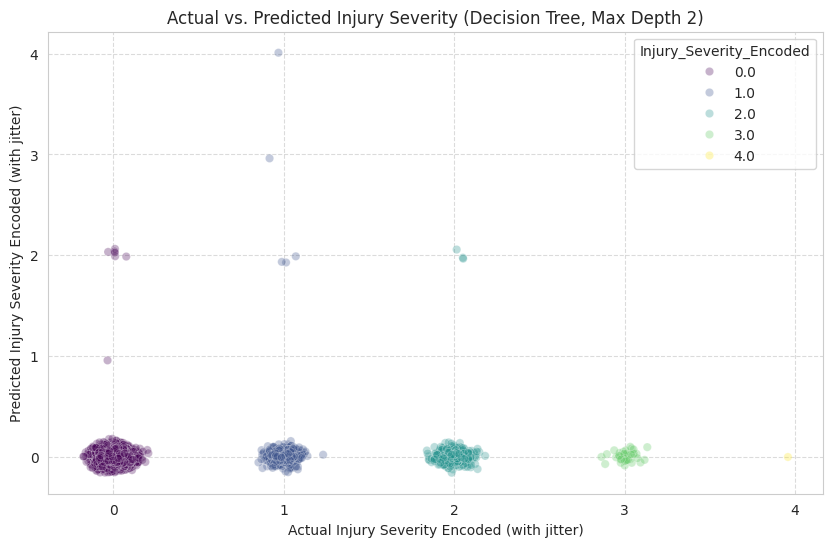

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=y_test + np.random.normal(0, 0.05, len(y_test)),  # Add jitter for better visibility of discrete points
    y=dt_predictions_depth7 + np.random.normal(0, 0.05, len(dt_predictions_depth7)),
    alpha=0.3, # Adjust transparency for density
    hue=y_test, # Color by actual class
    palette='viridis'
)
plt.title('Actual vs. Predicted Injury Severity (Decision Tree, Max Depth 2)')
plt.xlabel('Actual Injury Severity Encoded (with jitter)')
plt.ylabel('Predicted Injury Severity Encoded (with jitter)')
plt.xticks(np.unique(y_test)) # Ensure x-axis ticks align with actual categories
plt.yticks(np.unique(dt_predictions_depth7)) # Ensure y-axis ticks align with predicted categories
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

----------------

##Comparing Evaluations of models of DecisionTreeClassifier, RandomForestClassifier, and GradientBoostingClassifier for Max Depth = 7

<br>

| Model                            | Gini Impurity      | Accuracy Score     |
|:---------------------------------|:-------------------|:-------------------|
| DecisionTreeClassifier           | 0.294              | 0.825              |
| RandomForestClassifier           | 0.295              | 0.825              |
| GradientBoostingClassifier       | 0.057              | 0.786              |
|                                  |                    |                    |

<br>



--------------
##Analysis

###Which model is better?

The Gradient Boosting Model has a beter purity score, but the Decision Tree and Random Forest Classifiers have higher accuracy scores.   

Gradient Boosting produces purer leaves, as analysts say is often the case.  

However, if the goal is to have a model that more accurately predicts Injury Severity based on new data, one of the other models should be used.

The Decision Tree has a slightly better purity score than the Random Forest.  
Against instinct and my preditions, it seems the single Decision Tree model is the one to use, in this case.  

I suspect the overall model is not very useful, though.  I think the reason accuracy is so high is just because the number of "no injury" and "minor injury" cases is so vast compared to the overall data (89%), that it makes sense to almost always guess that the injury is of least severity.  

In future, I attempt to will test these models on more evenly distributed data.

##Feature Importance
The three most important features for predicting injury severity are Vehicle Damage,  
the Speed Limit, and Ambient Light.  
Note:  does not prove causation.

-----------

------------------

##Encoding Keys

![Encoding key 1](https://raw.githubusercontent.com/Alissa-Ouspen/data201_alissa/main/final/encoding_key_1.png)

![Encoding key 2](https://raw.githubusercontent.com/Alissa-Ouspen/data201_alissa/main/final/encoding_key_2.png)


Ignore
####AI use tracker:  

 - Help compare the gini impurity and the accuracy scores of Decision Tree Classifier, Random Forest Classifier, and Gradient Boosting Classifier

 - Help build a function that calculates Gini impurity more efficiently

 - How can I tell which features are the most important?
